In [94]:
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [95]:
TIME_STR = "20250728-125341"
FOLDER_PATH = f"data/{TIME_STR}"
SERVO_COMMAND_FILE_PATH = f"{FOLDER_PATH}/servo_command.csv"
SERVO_STATE_FILE_PATH = f"{FOLDER_PATH}/servo_state.csv"

POSITION_COMMAND_FILE_PATH = f"{FOLDER_PATH}/position_command.csv"
POSITION_STATE_FILE_PATH = f"{FOLDER_PATH}/position_state.csv"

NUM_JOINTS = 6
NUM_SERVOS = 7
COLORS = ["red", "orange", "brown", "green", "blue", "purple", "magenta"]
OPACITY_CMD = 1
OPACITY_STATE = 1
MARKER_SIZE = 1

In [96]:
servo_cmd = pd.read_csv(SERVO_COMMAND_FILE_PATH)
# servo_cmd

In [97]:
servo_state = pd.read_csv(SERVO_STATE_FILE_PATH)
# servo_state

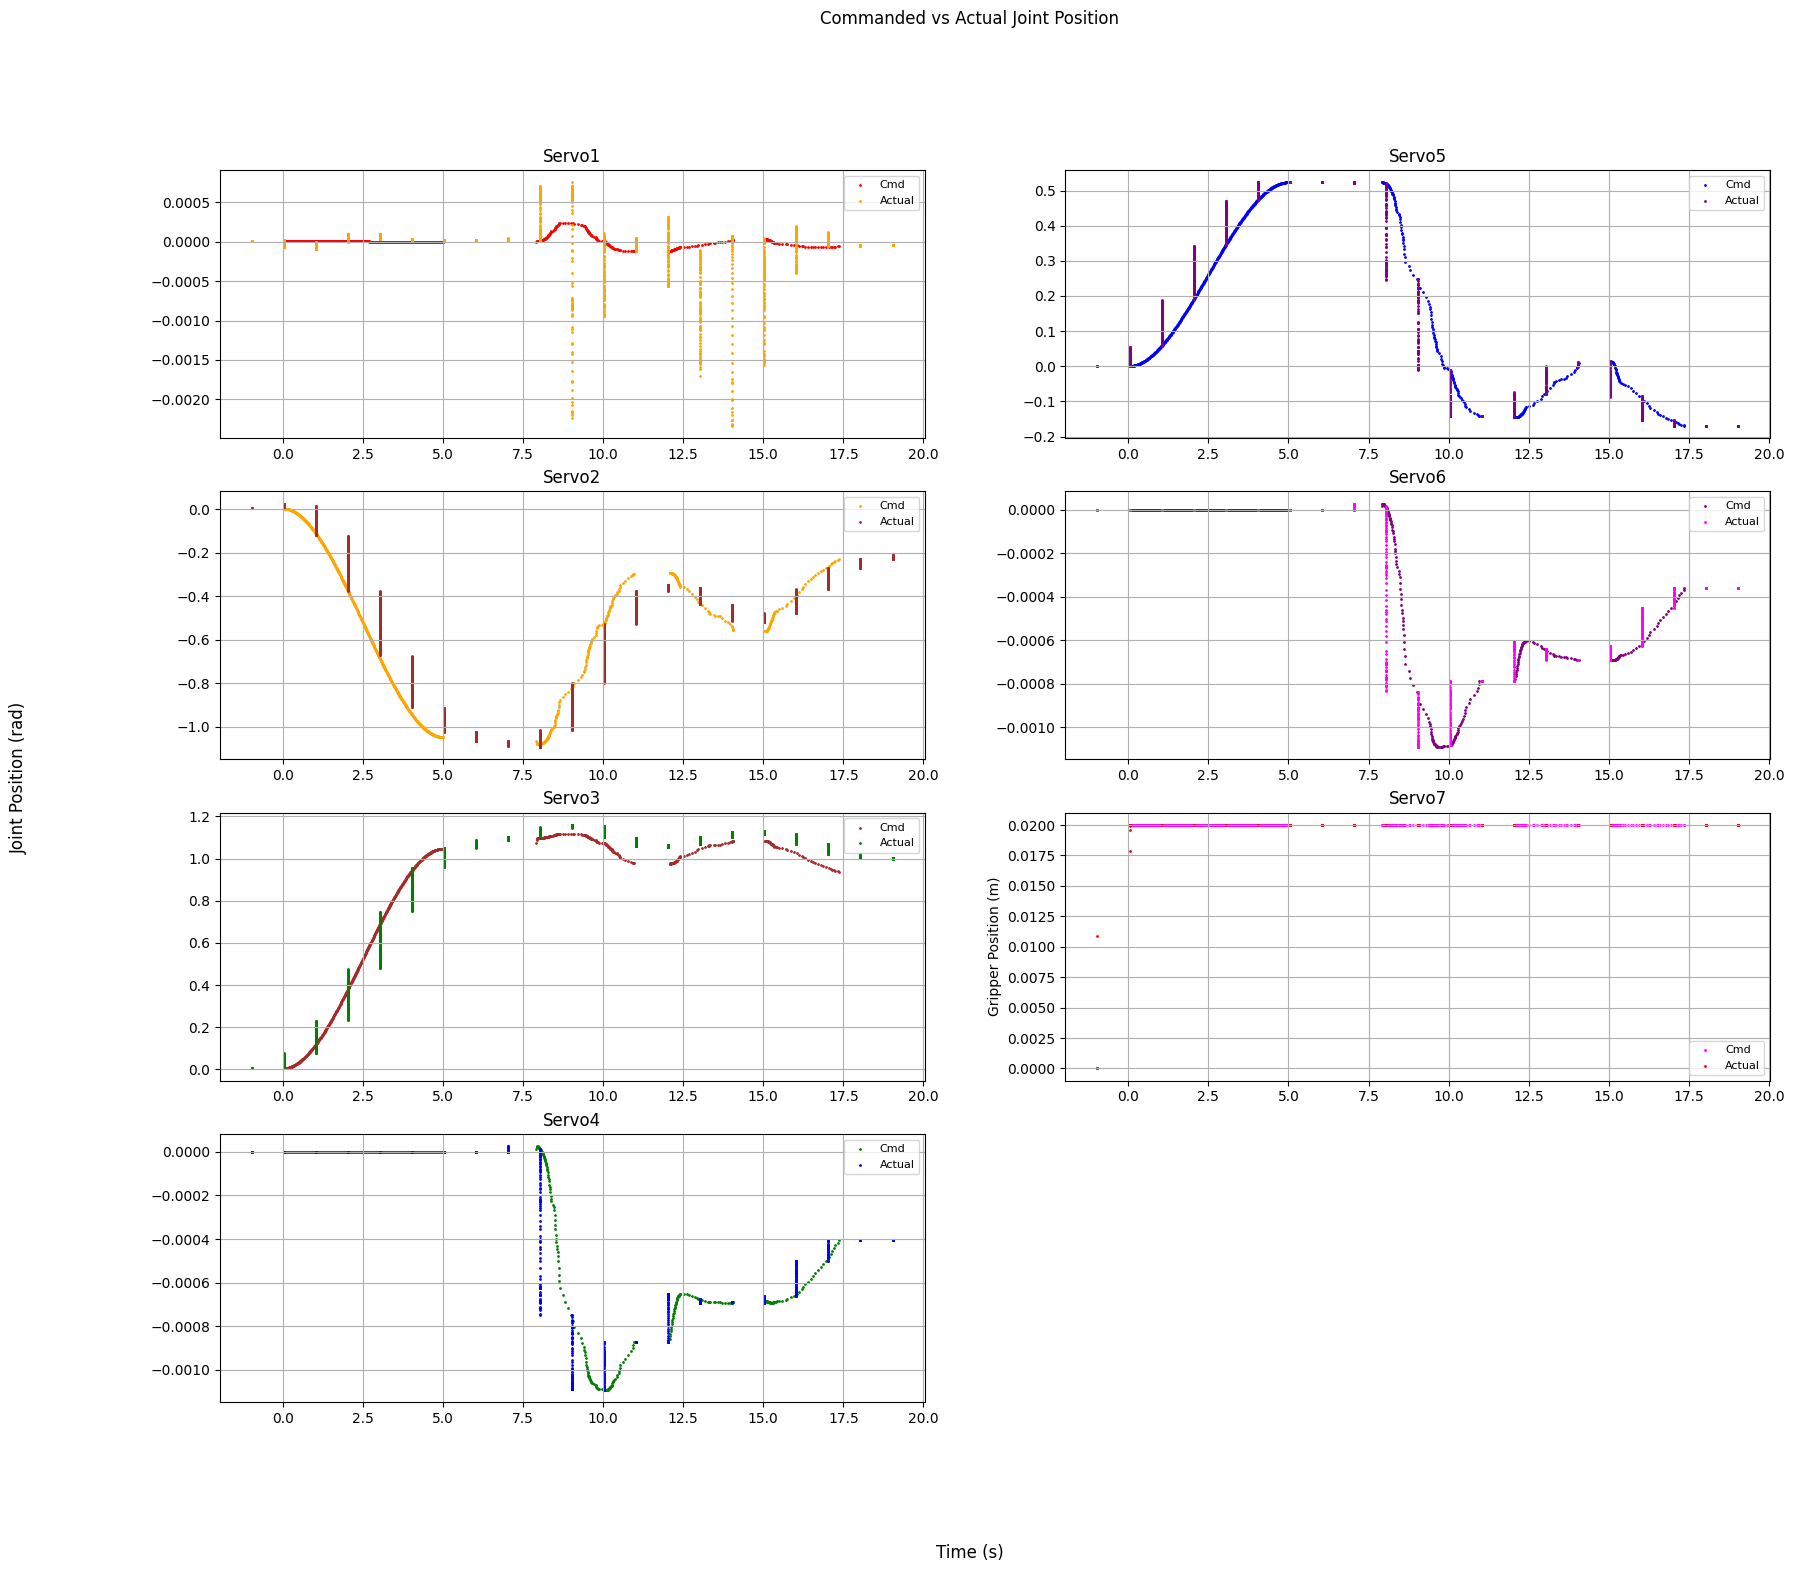

In [98]:
# fig, axes = plt.subplots(2, 4, constrained_layout=True)
fig, axes = plt.subplots(4, 2, figsize=(20, 16))
                         
for i in range(NUM_SERVOS + 1):
    col = i // 4
    row = i % 4

    if i == NUM_SERVOS:
        axes[row, col].set_visible(False)
        break

    # Plot servo{i} from command data
    axes[row, col].scatter(
        servo_cmd['time'], 
        servo_cmd[f'servo{i + 1}'], 
        label='Cmd', 
        color=COLORS[i],
        alpha=OPACITY_CMD,
        s=MARKER_SIZE
    )

    # Plot servo{i} from state data
    axes[row, col].scatter(
        servo_state['time'], 
        servo_state[f'servo{i + 1}'], 
        label='Actual', 
        color=COLORS[i + 1] if i < NUM_JOINTS else COLORS[0], 
        alpha=OPACITY_STATE,
        s=MARKER_SIZE
    )

    axes[row, col].set_title(f"Servo{i + 1}")
    axes[row, col].legend(fontsize=8, loc='best')

    if i + 1 == NUM_SERVOS:
        axes[row, col].set_ylabel("Gripper Position (m)")

    axes[row, col].grid()

# Add labels and title
fig.supxlabel('Time (s)')
fig.supylabel('Joint Position (rad)')
fig.suptitle('Commanded vs Actual Joint Position')

plt.show()

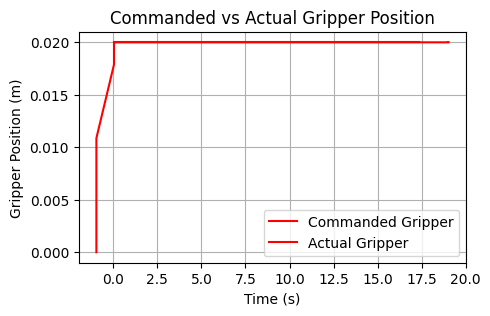

In [99]:
# Create a figure and axis
plt.figure(figsize=(5, 3))


# Plot servo{i} from command data
plt.plot(
    servo_cmd['time'], 
    servo_cmd[f'servo{NUM_SERVOS}'], 
    label='Commanded Gripper', 
    color=COLORS[0]
)

# Plot servo{i} from state data
plt.plot(
    servo_state['time'], 
    servo_state[f'servo{NUM_SERVOS}'], 
    label='Actual Gripper', 
    color=COLORS[0], 
    alpha=OPACITY_STATE
)

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Gripper Position (m)')
plt.title('Commanded vs Actual Gripper Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

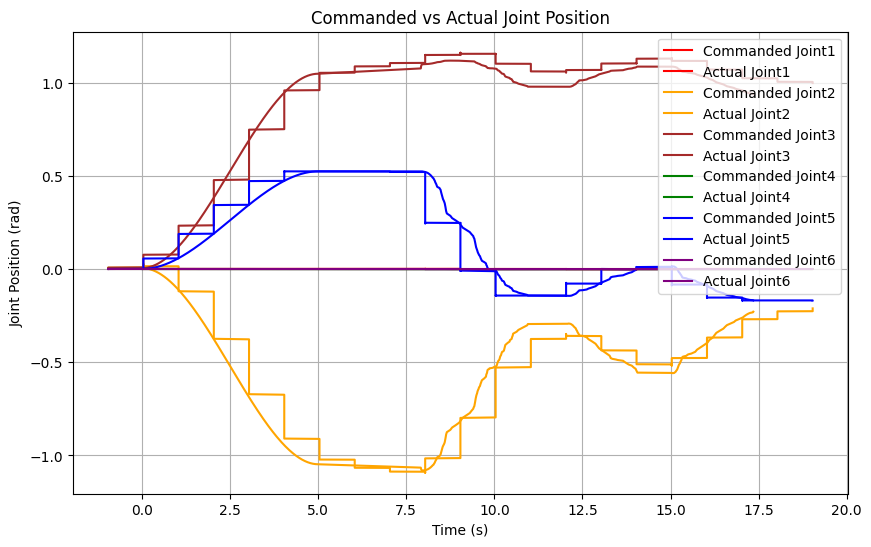

In [100]:
# Create a figure and axis
plt.figure(figsize=(10, 6))

for i in range(NUM_JOINTS):
    # Plot servo{i} from command data
    plt.plot(
        servo_cmd['time'], 
        servo_cmd[f'servo{i + 1}'], 
        label=f'Commanded Joint{i + 1}', 
        color=COLORS[i]
    )

    # Plot servo{i} from state data
    plt.plot(
        servo_state['time'], 
        servo_state[f'servo{i + 1}'], 
        label=f'Actual Joint{i + 1}', 
        color=COLORS[i], 
        alpha=OPACITY_STATE
    )

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Joint Position (rad)')
plt.title('Commanded vs Actual Joint Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

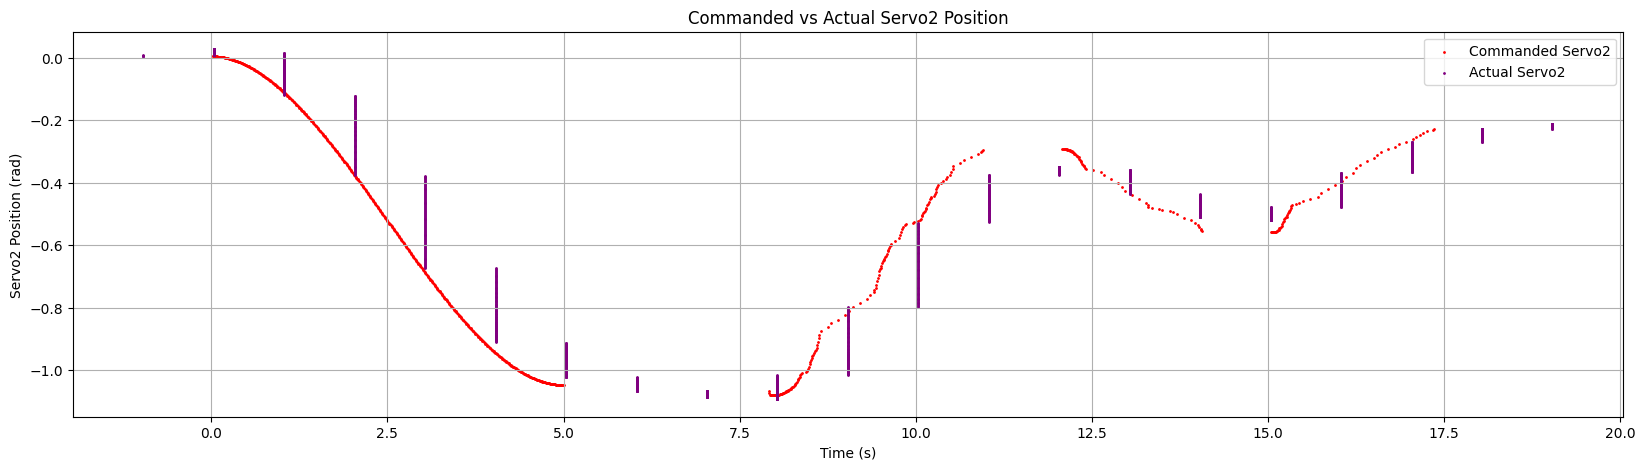

In [101]:
# Create a figure and axis
plt.figure(figsize=(20, 5))

servo_num = 2
# Plot servo{i} from command data
plt.scatter(
    servo_cmd['time'], 
    servo_cmd[f'servo{servo_num}'], 
    label=f'Commanded Servo{servo_num}', 
    color=COLORS[0],
    s=MARKER_SIZE
)

# Plot servo{i} from state data
plt.scatter(
    servo_state['time'], 
    servo_state[f'servo{servo_num}'], 
    label=f'Actual Servo{servo_num}', 
    color=COLORS[5], 
    alpha=OPACITY_STATE,
    s=MARKER_SIZE
)

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel(f'Servo{servo_num} Position (rad)')
plt.title(f'Commanded vs Actual Servo{servo_num} Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [102]:
servo_cmd

,time,servo1,servo2,servo3,servo4,servo5,servo6,servo7
0,0.019763,0.000009,0.004731,0.004997,-6.765155e-08,0.000040,-3.442667e-09,0.02
1,0.029681,0.000009,0.004670,0.005057,-6.764762e-08,0.000071,-3.442467e-09,0.02
2,0.039572,0.000009,0.004584,0.005142,-6.764212e-08,0.000113,-3.442187e-09,0.02
3,0.049446,0.000009,0.004474,0.005251,-6.763502e-08,0.000168,-3.441826e-09,0.02
4,0.059529,0.000009,0.004338,0.005386,-6.762628e-08,0.000236,-3.441381e-09,0.02
...,...,...,...,...,...,...,...,...
759,17.151345,-0.000063,-0.245792,0.947972,-4.538804e-04,-0.162103,-4.053395e-04,0.02
760,17.201475,-0.000061,-0.240303,0.944618,-4.404265e-04,-0.164241,-3.925800e-04,0.02
761,17.251883,-0.000060,-0.235837,0.941882,-4.279596e-04,-0.165974,-3.808634e-04,0.02
762,17.341447,-0.000058,-0.232309,0.939720,-4.164767e-04,-0.167342,-3.701647e-04,0.02


In [103]:
servo_state

,time,servo1,servo2,servo3,servo4,servo5,servo6,servo7
0,-0.964099,0.000009,0.004778,0.004950,-6.765460e-08,0.000017,-3.442822e-09,-3.972748e-08
1,-0.964099,0.000010,0.005351,0.005512,-6.766529e-08,0.000017,-3.441164e-09,-3.381788e-08
2,-0.964099,0.000011,0.005919,0.006069,-6.766330e-08,0.000017,-3.442608e-09,-3.180204e-08
3,-0.964099,0.000012,0.006481,0.006621,-6.765547e-08,0.000017,-3.446126e-09,-3.259021e-08
4,-0.964099,0.000012,0.007053,0.007196,-3.773305e-08,0.000039,-7.590507e-08,1.086838e-02
...,...,...,...,...,...,...,...,...
1988,19.035901,-0.000039,-0.211801,0.997300,-4.053530e-04,-0.168542,-3.598349e-04,1.999993e-02
1989,19.035901,-0.000039,-0.211679,0.997249,-4.053530e-04,-0.168542,-3.598349e-04,1.999993e-02
1990,19.035901,-0.000039,-0.211559,0.997199,-4.053530e-04,-0.168542,-3.598349e-04,1.999993e-02
1991,19.035901,-0.000039,-0.211439,0.997149,-4.053529e-04,-0.168542,-3.598349e-04,1.999993e-02


In [104]:
position_cmd = pd.read_csv(POSITION_COMMAND_FILE_PATH)
position_cmd

,time,x,y,z
0,0.019763,0.282040,-0.001275,0.417186
1,0.029681,0.282023,-0.001275,0.417184
2,0.039572,0.282000,-0.001275,0.417181
3,0.049446,0.281970,-0.001275,0.417177
4,0.059529,0.281933,-0.001275,0.417172
...,...,...,...,...
759,17.151345,0.184221,-0.001277,0.231629
760,17.201475,0.185225,-0.001277,0.231629
761,17.251883,0.186030,-0.001277,0.231629
762,17.341447,0.186642,-0.001277,0.231629


In [105]:
position_state = pd.read_csv(POSITION_STATE_FILE_PATH)
position_state

,time,x,y,z
0,-0.964099,0.282053,-0.001275,0.417188
1,-0.964099,0.282250,-0.001275,0.416868
2,-0.964099,0.282445,-0.001275,0.416552
3,-0.964099,0.282639,-0.001275,0.416238
4,-0.964099,0.282835,-0.001275,0.415913
...,...,...,...,...
1988,19.035901,0.179735,-0.001280,0.214102
1989,19.035901,0.179755,-0.001280,0.214092
1990,19.035901,0.179776,-0.001280,0.214082
1991,19.035901,0.179796,-0.001280,0.214072


In [106]:
position_cmd.columns[1:]

Index(['x', 'y', 'z'], dtype='object')

x
y
z


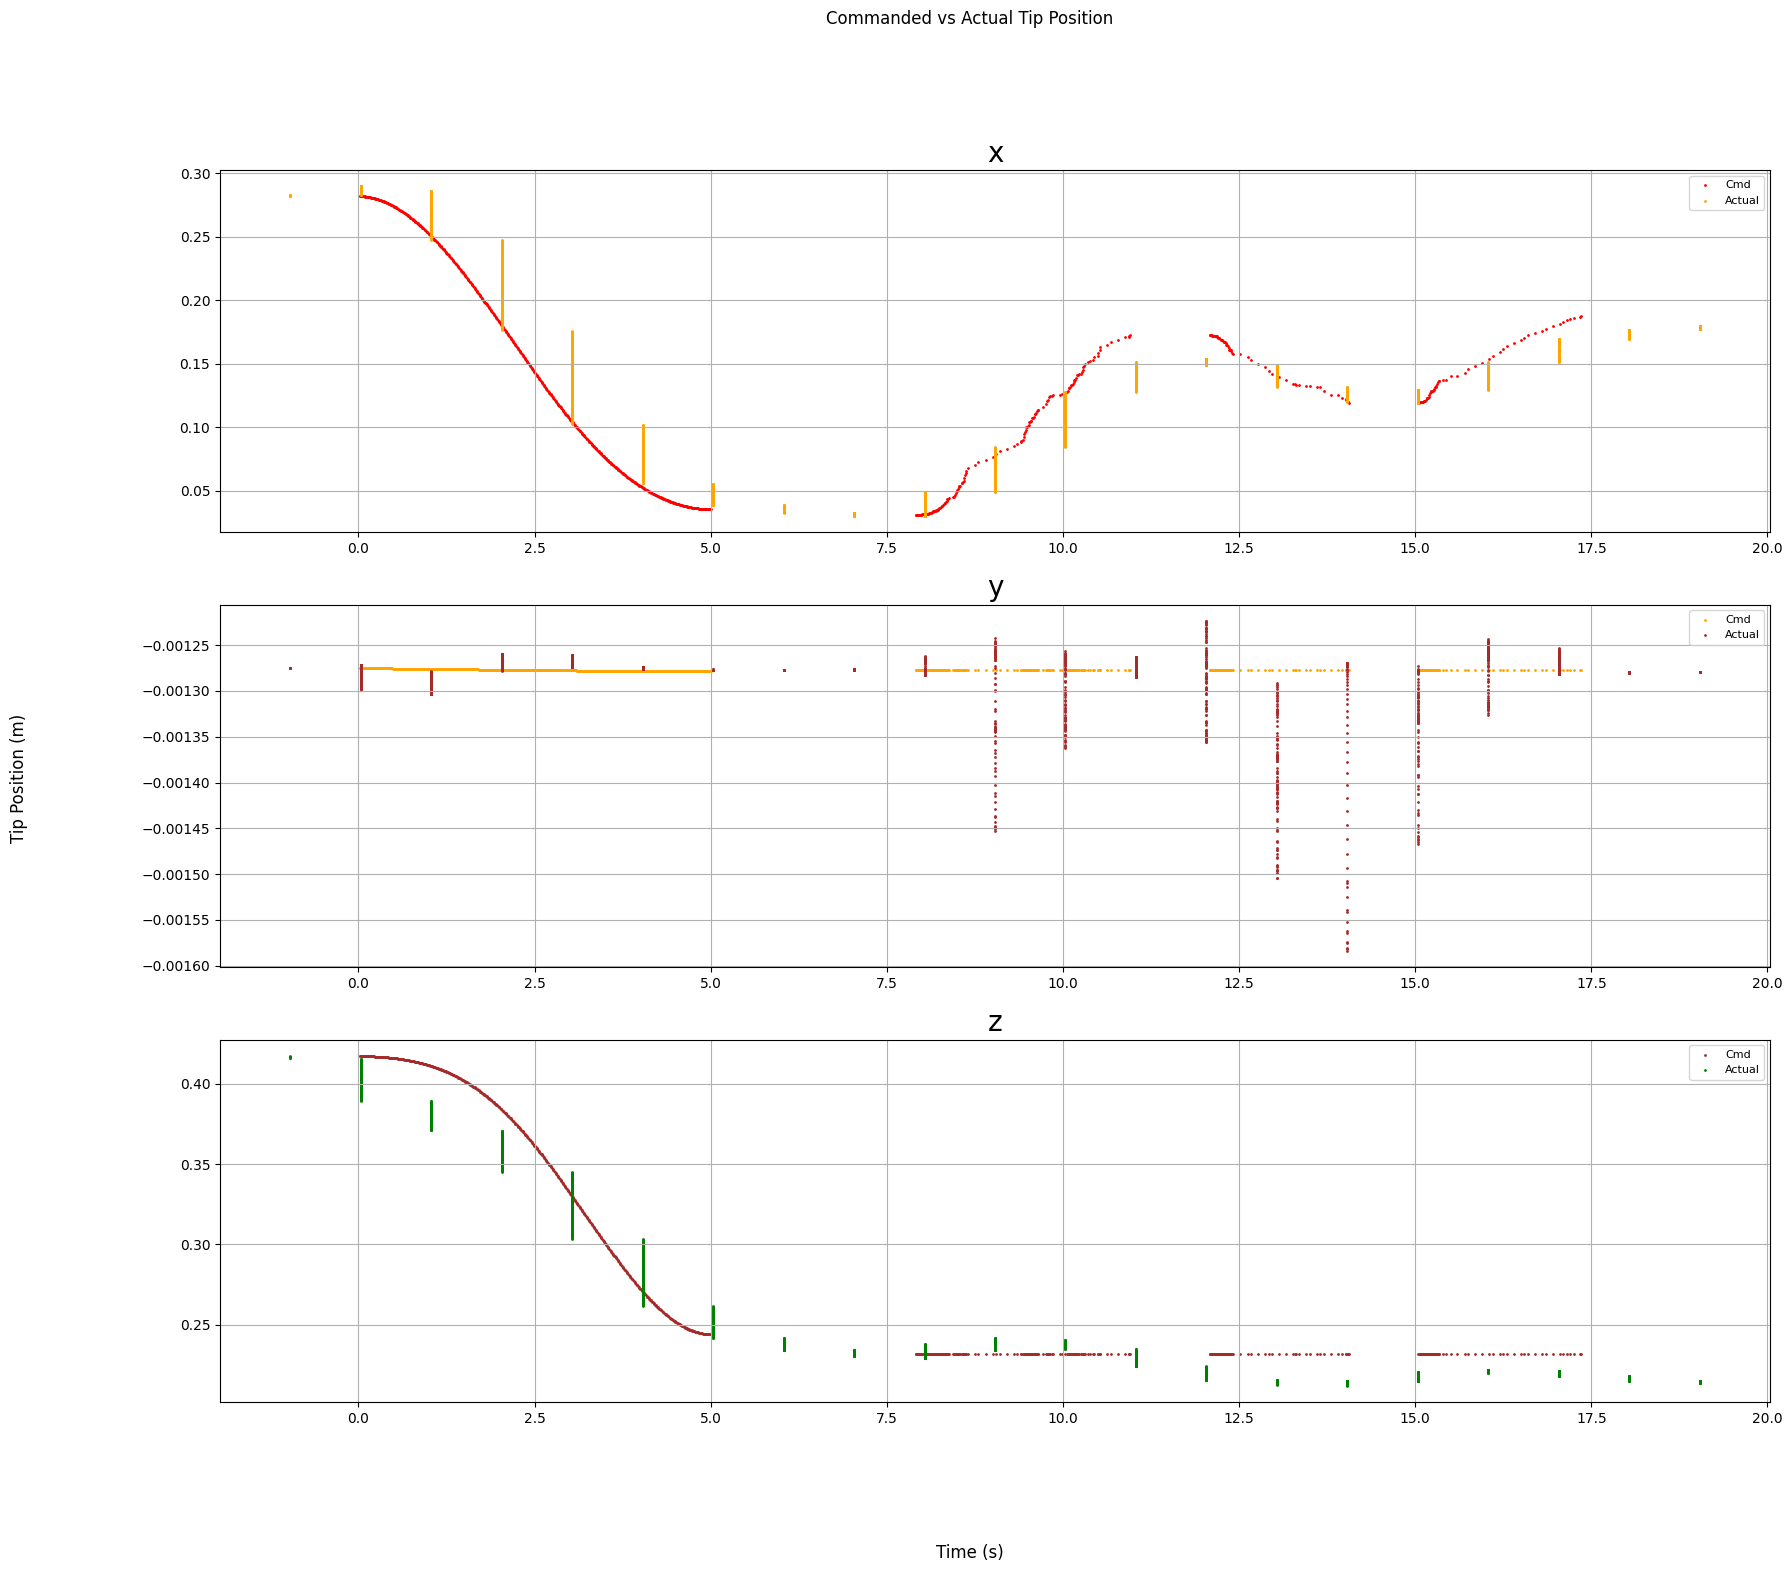

In [107]:
# fig, axes = plt.subplots(2, 4, constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 16))
                         
for i, column_name in enumerate(position_cmd.columns[1:]):
    print(column_name)
    # Plot x from command data
    axes[i].scatter(
        position_cmd['time'], 
        position_cmd[column_name], 
        label='Cmd', 
        color=COLORS[i],
        alpha=OPACITY_CMD,
        s=MARKER_SIZE
    )

    # Plot servo{i} from state data
    axes[i].scatter(
        position_state['time'], 
        position_state[column_name], 
        label='Actual', 
        color=COLORS[i + 1] if i < 3 else COLORS[0], 
        alpha=OPACITY_STATE,
        s=MARKER_SIZE
    )

    axes[i].set_title(column_name, size=20)
    axes[i].legend(fontsize=8, loc='best')
    axes[i].grid()

# Add labels and title
fig.supxlabel('Time (s)')
fig.supylabel('Tip Position (m)')
fig.suptitle('Commanded vs Actual Tip Position')

plt.show()